In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
import numpy as np
X = pd.read_csv("/content/drive/MyDrive/Dataset/X_processed.csv")


In [5]:
y = pd.read_csv("/content/drive/MyDrive/Dataset/y.csv")

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)


(5634, 32) (1409, 32)


In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train.values.ravel())

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_proba_lr))


              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409

ROC AUC: 0.8469012374383218


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train.values.ravel())

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.71      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC AUC: 0.8421646128807254


In [11]:
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))


              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC AUC: 0.8391782272856441


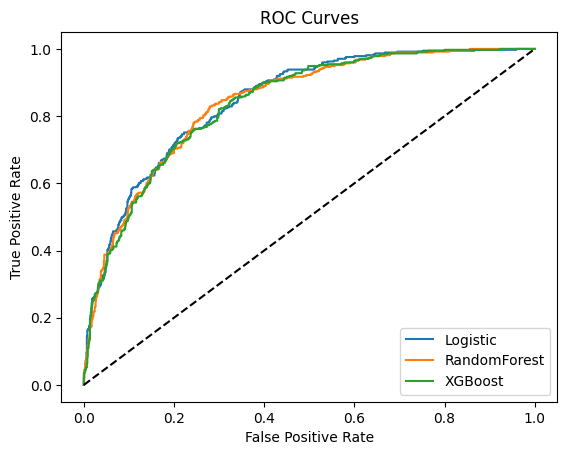

In [12]:
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.plot(fpr_lr, tpr_lr, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="RandomForest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


In [13]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score

results = []

# Logistic
results.append({
    "Model": "Logistic Regression",
    "ROC_AUC": roc_auc_score(y_test, y_proba_lr),
    "Recall_Churn": recall_score(y_test, y_pred_lr),
    "Precision_Churn": precision_score(y_test, y_pred_lr),
    "F1_Churn": f1_score(y_test, y_pred_lr)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    "ROC_AUC": roc_auc_score(y_test, y_proba_rf),
    "Recall_Churn": recall_score(y_test, y_pred_rf),
    "Precision_Churn": precision_score(y_test, y_pred_rf),
    "F1_Churn": f1_score(y_test, y_pred_rf)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    "ROC_AUC": roc_auc_score(y_test, y_proba_xgb),
    "Recall_Churn": recall_score(y_test, y_pred_xgb),
    "Precision_Churn": precision_score(y_test, y_pred_xgb),
    "F1_Churn": f1_score(y_test, y_pred_xgb)
})

results_df = pd.DataFrame(results)
results_df


,Model,ROC_AUC,Recall_Churn,Precision_Churn,F1_Churn
0,Logistic Regression,0.846901,0.521390,0.667808,0.585586
1,Random Forest,0.842165,0.711230,0.542857,0.615741
2,XGBoost,0.839178,0.524064,0.640523,0.576471
